In [ ]:
#We will utilize the yfinance library to retrieve historical volatility data and implement the GARCH 
#(Generalized Autoregressive Conditional Heteroskedasticity) model to estimate and forecast volatility.
#Volatility is a crucial aspect of financial markets as it measures the degree of variation in the price of a financial instrument over time. 
#Accurate volatility forecasting can assist traders and investors in making informed decisions and managing risk effectively.

In [1]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
%matplotlib inline
import seaborn as sns
from datetime import datetime

In [3]:
import yfinance as yf
# Retrieve historical volatility data for GS
stock = yf.Ticker("GS")
volatility_data = stock.history(period="max")
# Fetch last 5 years instead of max
volatility_data = stock.history(period="5y")

YFRateLimitError: Too Many Requests. Rate limited. Try after a while.

In [4]:
from alpha_vantage.timeseries import TimeSeries

# Set your API key
api_key = "YOUR_ALPHA_VANTAGE_KEY"

# Create TimeSeries object
ts = TimeSeries(key=api_key, output_format="pandas")

# Get daily stock data for Goldman Sachs (GS)
volatility_data, meta_data = ts.get_daily(symbol="GS", outputsize="full")

# Display last few rows of the DataFrame
print(volatility_data.tail())

            1. open  2. high  3. low  4. close  5. volume
date                                                     
1999-11-05    72.00    74.31   71.25     73.69  1304900.0
1999-11-04    69.69    70.75   69.44     70.13   570400.0
1999-11-03    69.81    69.88   68.31     68.75   924000.0
1999-11-02    69.19    71.75   69.13     69.75   543000.0
1999-11-01    70.50    71.00   69.31     69.38   949300.0


In [ ]:
#The history method retrieves historical price data for the specified stock symbol. 
#By setting the period parameter to "max", we retrieve the entire available history of the stock.

In [5]:
volatility_data.head()

,1. open,2. high,3. low,4. close,5. volume
date,,,,,
2025-03-14,533.99,543.57,526.70,541.41,2808108.0
2025-03-13,535.67,538.14,520.06,524.81,2529106.0
2025-03-12,544.00,545.00,528.59,535.71,3078055.0
2025-03-11,532.47,539.99,524.20,531.43,4190502.0
2025-03-10,542.30,546.47,523.13,531.66,5211055.0


In [7]:
#The columns represent:
#Open: Opening price of the stock
#High: Highest price during the trading day
#Low: Lowest price during the trading day
#Close: Closing price of the stock
#Volume: Number of shares traded

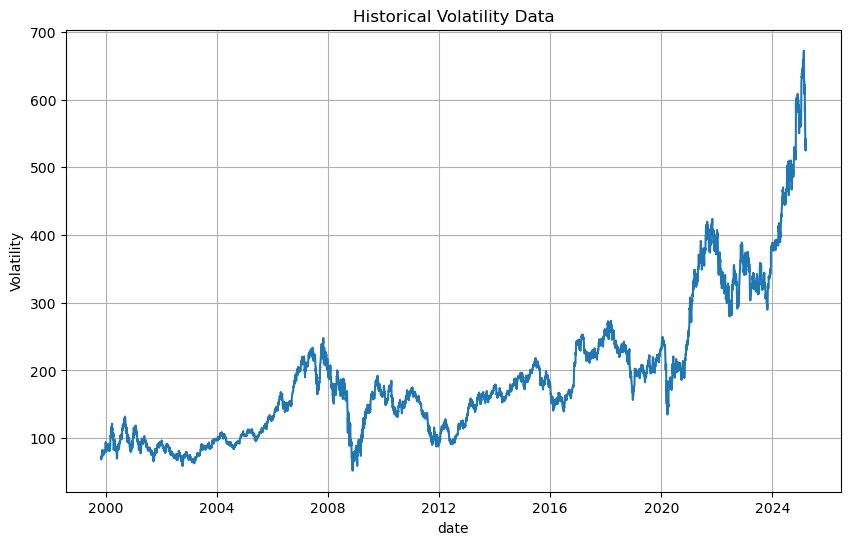

In [6]:
# Plot the historical volatility data
plt.figure(figsize=(10, 6))
plt.plot(volatility_data.index, volatility_data["4. close"])
plt.xlabel("date")
plt.ylabel("Volatility")
plt.title("Historical Volatility Data")
plt.grid(True)

plt.show()

In [ ]:
#The line plot provides a visual representation of the volatility data over time. 
#It helps us identify any trends, seasonality, or outliers present in the data.

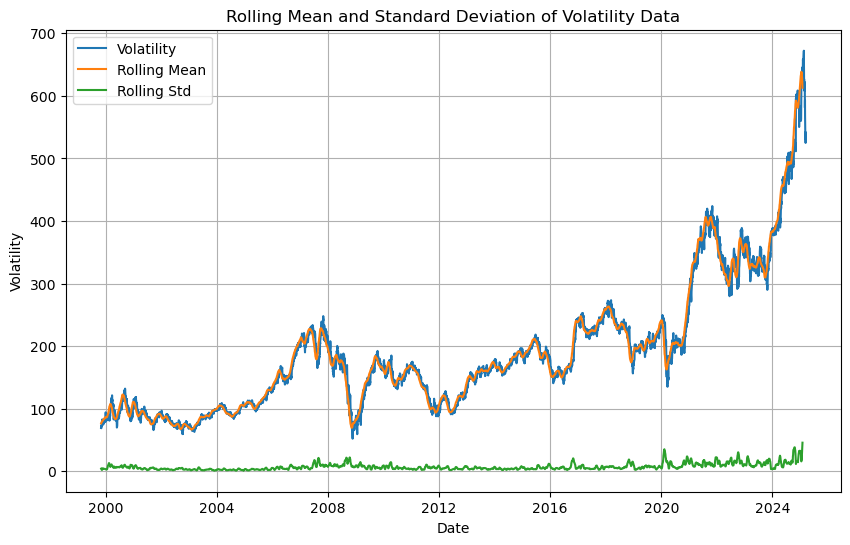

In [9]:
# Calculate the rolling mean and standard deviation
rolling_mean = volatility_data["4. close"].rolling(window=30).mean()
rolling_std = volatility_data["4. close"].rolling(window=30).std()

# Plot the rolling mean and standard deviation
plt.figure(figsize=(10, 6))
plt.plot(volatility_data.index, volatility_data["4. close"], label="Volatility")
plt.plot(rolling_mean.index, rolling_mean, label="Rolling Mean")
plt.plot(rolling_std.index, rolling_std, label="Rolling Std")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title("Rolling Mean and Standard Deviation of Volatility Data")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#The rolling mean and standard deviation provide insights into the long-term trends and volatility clustering in the data. 
#They help us identify periods of high and low volatility.

In [10]:
!pip install arch

Defaulting to user installation because normal site-packages is not writeable


In [11]:
from arch import arch_model

In [13]:
# Calculate log returns
returns = np.log(volatility_data["4. close"]).diff().dropna()

In [ ]:
#The log returns represent the percentage change in the volatility data from one period to the next. 
# log returns Stabilizes variance: Unlike raw percentage returns, log returns make time series more stationary.
#They are commonly used in financial analysis as they provide a more meaningful representation of the data.

In [33]:
# Fit an ARCH(1) model to the returns data
model_arch = arch_model(returns, vol='ARCH', p=1)  # p=1 for ARCH(1)
model_fit_arch = model_arch.fit()

Iteration:      1,   Func. Count:      5,   Neg. LLF: 9060682686.880287
Iteration:      2,   Func. Count:     17,   Neg. LLF: 115484.59408854028
Iteration:      3,   Func. Count:     28,   Neg. LLF: 82095.54311737603
Iteration:      4,   Func. Count:     39,   Neg. LLF: 17389.692298729824
Iteration:      5,   Func. Count:     48,   Neg. LLF: 391322573.3649156
Iteration:      6,   Func. Count:     60,   Neg. LLF: 7127.860752284283
Iteration:      7,   Func. Count:     68,   Neg. LLF: 3308481312.228929
Iteration:      8,   Func. Count:     79,   Neg. LLF: -15766.910157936876
Optimization terminated successfully    (Exit mode 0)
            Current function value: -15766.910156384656
            Iterations: 12
            Function evaluations: 79
            Gradient evaluations: 8


C:\Users\Tanvi.Koyande\AppData\Roaming\Python\Python311\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0005077. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


In [34]:
# Output the model summary
print(model_fit_arch.summary())

                      Constant Mean - ARCH Model Results                      
Dep. Variable:               4. close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:                15766.9
Distribution:                  Normal   AIC:                          -31527.8
Method:            Maximum Likelihood   BIC:                          -31507.5
                                        No. Observations:                 6380
Date:                Mon, Mar 17 2025   Df Residuals:                     6379
Time:                        09:33:57   Df Model:                            1
                                   Mean Model                                  
                  coef    std err          t      P>|t|        95.0% Conf. Int.
-------------------------------------------------------------------------------
mu         -7.8477e-04  2.724e-04     -2.881  3.9

In [40]:
volatility_arch = model_fit_arch.conditional_volatility

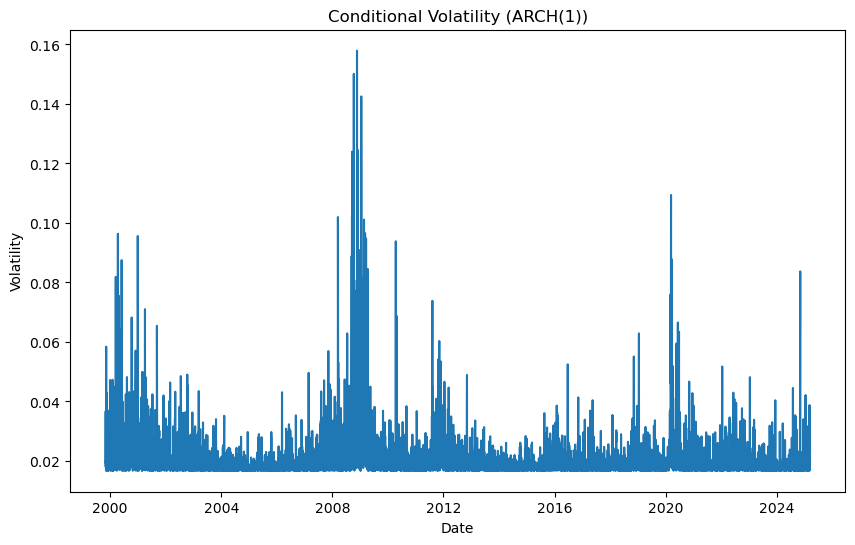

In [41]:
# Plot the conditional volatility (estimated volatility)
plt.figure(figsize=(10, 6))
plt.plot(volatility_arch)
plt.title('Conditional Volatility (ARCH(1))')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

In [42]:
# Calculate the mean absolute error (MAE)
mae = np.mean(np.abs(volatility_arch - returns))
print("Mean Absolute Error (MAE):", mae)

# Calculate the root mean squared error (RMSE)
rmse = np.sqrt(np.mean((volatility_arch - returns) ** 2))
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 0.024567539072572156
Root Mean Squared Error (RMSE): 0.031761282698534544


In [ ]:
#GARCH (Generalized Autoregressive Conditional Heteroskedasticity) model. 
#A GARCH model is an extension of the ARCH model and is typically more flexible. 
#It includes both past squared residuals (like ARCH) and past conditional variances (volatility) in the model.

In [14]:
# Fit the GARCH(1, 1) model
model = arch_model(returns, vol="Garch", p=1, q=1)
results = model.fit()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 1.6183253882782472e+21
Iteration:      2,   Func. Count:     19,   Neg. LLF: 13896245396134.697
Iteration:      3,   Func. Count:     33,   Neg. LLF: -16451.56936714834
Optimization terminated successfully    (Exit mode 0)
            Current function value: -16451.569378127955
            Iterations: 7
            Function evaluations: 33
            Gradient evaluations: 3


C:\Users\Tanvi.Koyande\AppData\Roaming\Python\Python311\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0005077. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


In [15]:
#we are fitting a GARCH(1, 1) model, which includes one lag of both the returns and the conditional variance

In [16]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:               4. close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                16451.6
Distribution:                  Normal   AIC:                          -32895.1
Method:            Maximum Likelihood   BIC:                          -32868.1
                                        No. Observations:                 6380
Date:                Mon, Mar 17 2025   Df Residuals:                     6379
Time:                        09:28:53   Df Model:                            1
                                   Mean Model                                  
===============================================================================
                  coef    std err          t      P>|t|        95.0% Conf. Int.
-------------------------------------------------------------------------------
mu         -7.6560e-04  1.967e-04     -3.893  9.906e-05 [-1.151e-03,-3.801e-04]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      1.0155e-05  4.509e-12  2.252e+06      0.000 [1.015e-05,1.015e-05]
alpha[1]       0.1000  1.174e-02      8.514  1.675e-17   [7.698e-02,  0.123]
beta[1]        0.8800  8.678e-03    101.410      0.000     [  0.863,  0.897]
============================================================================

Covariance estimator: robust
"""

In [ ]:
#Once we have fitted the GARCH model, we can estimate and forecast the volatility. 
#The estimated volatility represents the conditional variance of the log returns, while the forecasted volatility provides future volatility predictions.

In [17]:
# Estimate the volatility
volatility = results.conditional_volatility

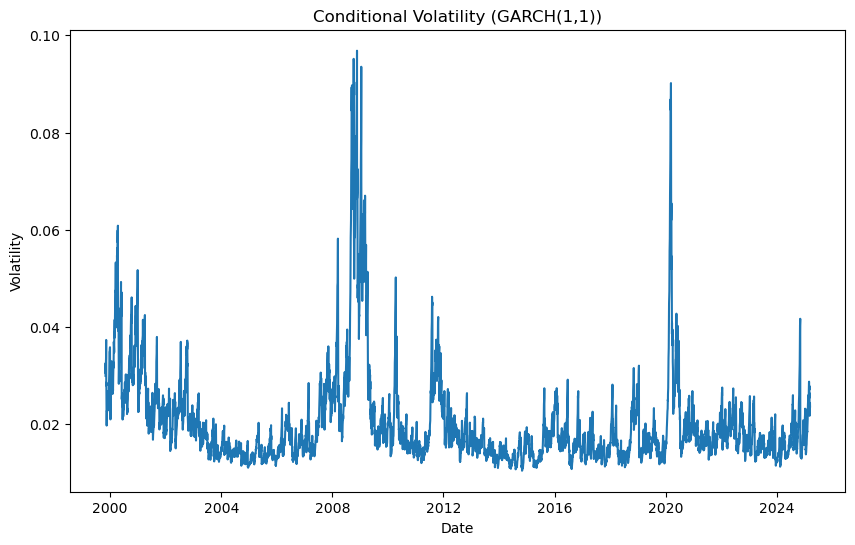

In [36]:
# Plot the conditional volatility (estimated volatility)
plt.figure(figsize=(10, 6))
plt.plot(volatility)
plt.title('Conditional Volatility (GARCH(1,1))')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

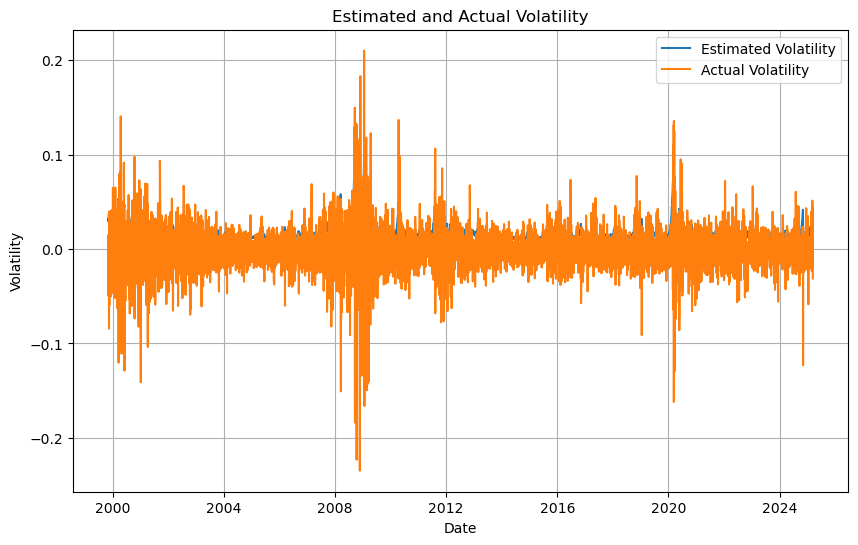

In [18]:
# Plot the estimated and actual volatility
plt.figure(figsize=(10, 6))
plt.plot(volatility.index, volatility, label="Estimated Volatility")
plt.plot(returns.index, returns, label="Actual Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title("Estimated and Actual Volatility")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#The plot shows the estimated volatility (conditional variance) and the actual volatility (log returns) over time. 
#It helps us assess the accuracy of the volatility estimates

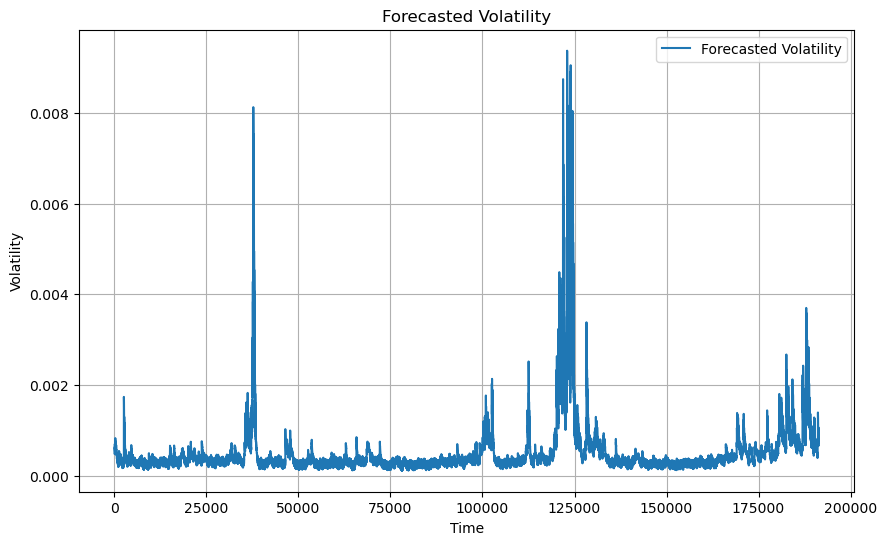

In [19]:
# Forecast the volatility
forecast = results.forecast(start=0, horizon=30)
forecast_volatility = forecast.variance.dropna().values.flatten()

# Plot the forecasted volatility
plt.figure(figsize=(10, 6))
plt.plot(forecast_volatility, label="Forecasted Volatility")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.title("Forecasted Volatility")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#The plot displays the forecasted volatility for the next 30 periods. 
#It provides insights into the expected future volatility based on the GARCH model.

In [20]:
# Calculate the mean absolute error (MAE)
mae = np.mean(np.abs(volatility - returns))
print("Mean Absolute Error (MAE):", mae)

# Calculate the root mean squared error (RMSE)
rmse = np.sqrt(np.mean((volatility - returns) ** 2))
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 0.02339652329893875
Root Mean Squared Error (RMSE): 0.031433664716786394


In [ ]:
#The MAE and RMSE provide measures of the average and overall forecast errors, respectively. 
#Lower values indicate better model performance.

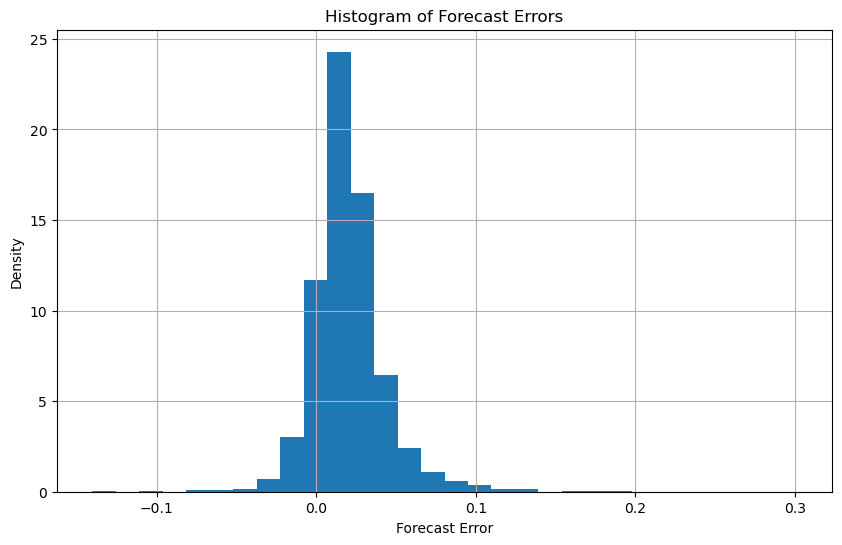

In [21]:
# Calculate the forecast errors
errors = volatility - returns

# Plot the histogram of forecast errors
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=30, density=True)
plt.xlabel("Forecast Error")
plt.ylabel("Density")
plt.title("Histogram of Forecast Errors")
plt.grid(True)

plt.show()

In [22]:
#The histogram provides insights into the distribution of forecast errors. 
#It helps us assess the accuracy and reliability of the volatility forecasts.

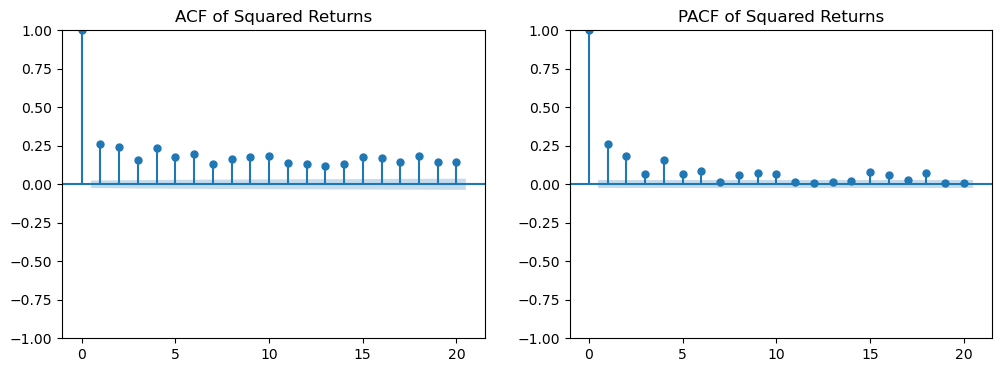

In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF of squared returns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(returns**2, lags=20, ax=axes[0])
axes[0].set_title("ACF of Squared Returns")

plot_pacf(returns**2, lags=20, ax=axes[1])
axes[1].set_title("PACF of Squared Returns")

plt.show()

In [ ]:
#From your ACF and PACF plots of squared returns, we can determine the GARCH(p, q) parameters as follows:

#q (MA component in volatility - from ACF)
#The ACF plot shows significant spikes at lags 1, 2, and possibly 3 before tapering off.
#This suggests that q = 2 or 3 might be a good choice.

#p (AR component in volatility - from PACF)
#The PACF plot shows significant spikes at lags 1 and 2, after which it dies down.
#This suggests that p = 2 might be appropriate.
#Suggested Model: GARCH(2,2) or GARCH(2,3)
#You can first try GARCH(2,2) and compare AIC/BIC with GARCH(2,3) to decide the best model.

In [24]:
# Fit the GARCH(2, 2) model
model1 = arch_model(returns, vol="Garch", p=2, q=2)
results1 = model1.fit()

Iteration:      1,   Func. Count:      8,   Neg. LLF: 6204298221.272323
Iteration:      2,   Func. Count:     23,   Neg. LLF: 6.372622570157103e+17
Iteration:      3,   Func. Count:     40,   Neg. LLF: 440519668.2211976
Iteration:      4,   Func. Count:     54,   Neg. LLF: -16445.652015958476
Optimization terminated successfully    (Exit mode 0)
            Current function value: -16445.65204025083
            Iterations: 8
            Function evaluations: 54
            Gradient evaluations: 4


C:\Users\Tanvi.Koyande\AppData\Roaming\Python\Python311\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0005077. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


In [25]:
results1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:               4. close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                16445.7
Distribution:                  Normal   AIC:                          -32879.3
Method:            Maximum Likelihood   BIC:                          -32838.7
                                        No. Observations:                 6380
Date:                Mon, Mar 17 2025   Df Residuals:                     6379
Time:                        09:31:15   Df Model:                            1
                                   Mean Model                                  
===============================================================================
                  coef    std err          t      P>|t|        95.0% Conf. Int.
-------------------------------------------------------------------------------
mu         -6.9002e-04  2.081e-04     -3.316  9.116e-04 [-1.098e-03,-2.822e-04]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      1.0155e-05  1.790e-11  5.674e+05      0.000 [1.016e-05,1.016e-05]
alpha[1]       0.0500  4.910e-02      1.018      0.309  [-4.623e-02,  0.146]
alpha[2]       0.0500  8.215e-02      0.609      0.543     [ -0.111,  0.211]
beta[1]        0.4400      1.091      0.403      0.687     [ -1.698,  2.578]
beta[2]        0.4400      1.060      0.415      0.678     [ -1.638,  2.518]
============================================================================

Covariance estimator: robust
"""

In [27]:
volatility1 = results1.conditional_volatility

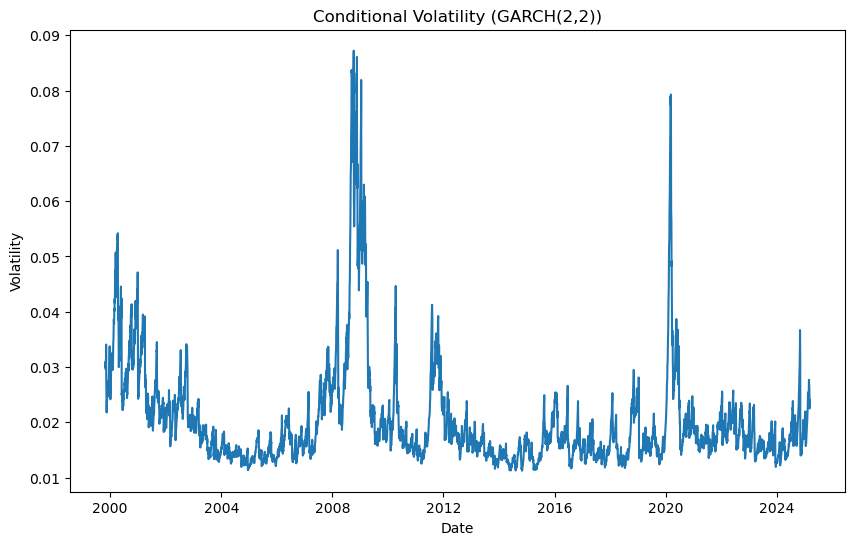

In [38]:
# Plot the conditional volatility (estimated volatility)
plt.figure(figsize=(10, 6))
plt.plot(volatility1)
plt.title('Conditional Volatility (GARCH(2,2))')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

In [28]:
# Calculate the mean absolute error (MAE)
mae1 = np.mean(np.abs(volatility1 - returns))
print("Mean Absolute Error (MAE):", mae1)

# Calculate the root mean squared error (RMSE)
rmse1 = np.sqrt(np.mean((volatility1 - returns) ** 2))
print("Root Mean Squared Error (RMSE):", rmse1)

Mean Absolute Error (MAE): 0.023531555377315296
Root Mean Squared Error (RMSE): 0.031495159355198164


In [29]:
# Fit the GARCH(2, 3) model
model2 = arch_model(returns, vol="Garch", p=2, q=3)
results2 = model2.fit()

Iteration:      1,   Func. Count:      9,   Neg. LLF: 13311460901.877747
Iteration:      2,   Func. Count:     25,   Neg. LLF: 7.001262025820466e+20
Iteration:      3,   Func. Count:     41,   Neg. LLF: 3.726370961466182e+16
Iteration:      4,   Func. Count:     56,   Neg. LLF: -16449.573844165174
Optimization terminated successfully    (Exit mode 0)
            Current function value: -16449.573830181387
            Iterations: 8
            Function evaluations: 56
            Gradient evaluations: 4


C:\Users\Tanvi.Koyande\AppData\Roaming\Python\Python311\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0005077. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


In [30]:
results2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:               4. close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                16449.6
Distribution:                  Normal   AIC:                          -32885.1
Method:            Maximum Likelihood   BIC:                          -32837.8
                                        No. Observations:                 6380
Date:                Mon, Mar 17 2025   Df Residuals:                     6379
Time:                        09:31:29   Df Model:                            1
                                   Mean Model                                  
===============================================================================
                  coef    std err          t      P>|t|        95.0% Conf. Int.
-------------------------------------------------------------------------------
mu         -7.8244e-04  2.185e-04     -3.581  3.417e-04 [-1.211e-03,-3.542e-04]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      1.0155e-05  2.903e-11  3.498e+05      0.000 [1.016e-05,1.016e-05]
alpha[1]       0.1000  3.191e-02      3.133  1.728e-03   [3.745e-02,  0.163]
alpha[2]       0.1000  9.765e-02      1.024      0.306  [-9.139e-02,  0.291]
beta[1]        0.2600      0.741      0.351      0.726     [ -1.193,  1.713]
beta[2]        0.2600      0.870      0.299      0.765     [ -1.445,  1.965]
beta[3]        0.2600      0.321      0.810      0.418     [ -0.369,  0.889]
============================================================================

Covariance estimator: robust
"""

In [31]:
volatility2 = results2.conditional_volatility

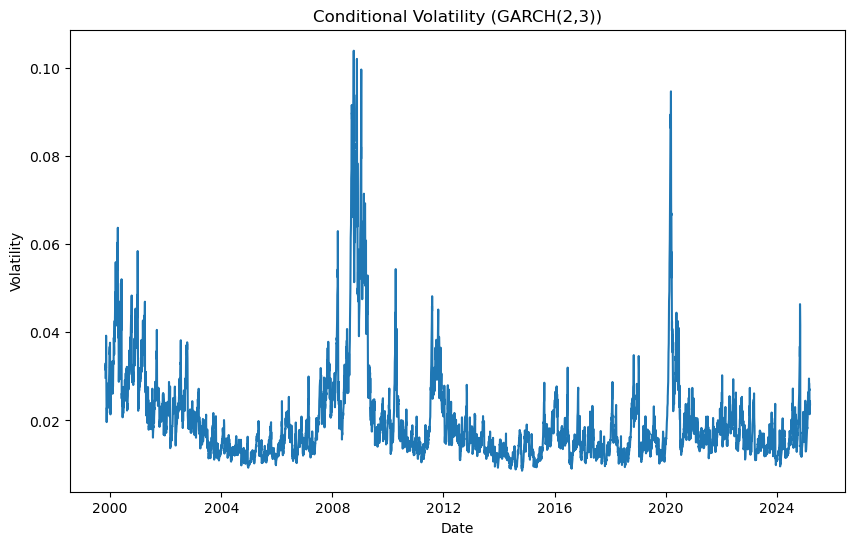

In [39]:
# Plot the conditional volatility (estimated volatility)
plt.figure(figsize=(10, 6))
plt.plot(volatility2)
plt.title('Conditional Volatility (GARCH(2,3))')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

In [43]:
pred2 = results2.forecast(horizon=7)

TypeError: float() argument must be a string or a real number, not 'ARCHModelForecast'

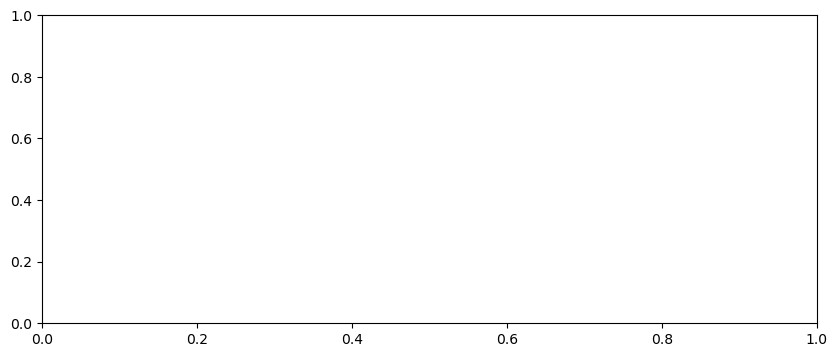

In [44]:
plt.figure(figsize=(10,4))
plt.plot(pred2)
plt.title('Volatility Prediction - Next 7 Days', fontsize=20)

In [32]:
# Calculate the mean absolute error (MAE)
mae2 = np.mean(np.abs(volatility2 - returns))
print("Mean Absolute Error (MAE):", mae2)

# Calculate the root mean squared error (RMSE)
rmse2 = np.sqrt(np.mean((volatility2 - returns) ** 2))
print("Root Mean Squared Error (RMSE):", rmse2)

Mean Absolute Error (MAE): 0.023067668667159518
Root Mean Squared Error (RMSE): 0.0313714895327571


In [ ]:
#Comparing mae and rmse
#ARCH (1)
#mae = 0.024567539072572156
#rmse = 0.031761282698534544

#GARCH(1,1)
#mae = 0.02339652329893875
#rmse = 0.031433664716786394

#GARCH(2,2)
#mae = 0.023531555377315296
#rmse = 0.031495159355198164


#GARCH(2,3)
#mae = 0.023067668667159518
#rmse = 0.0313714895327571
